# OpenCV - Panduan Lengkap Computer Vision
### Materi Pengajaran | Week 4

## 01 - Reading Images, Image filter, Video, Video filter, Webcam, Webcam filter


In [2]:
import cv2 
# Mengimpor OpenCV

import numpy as np
# Mengimpor NumPy

In [3]:
sumber_image = 'images/coba.jpg'
sumber_video = 'images/video.mp4'

#### a. Membaca Images

In [4]:
img = cv2.imread(sumber_image)

Penjelasan : 
- cv2.imread() membaca file gambar dari disk dan mengembalikan array NumPy 3D (tinggi x lebar x channel)
- Hasilnya bertipe uint8 dengan nilai 0-255 dalam format BGR

In [5]:
print('Tipe data gambar  :', type(img))
print('Shape gambar      :', img.shape)
print('Ukuran total pixel:', img.size)
print('Tipe elemen       :', img.dtype)

Tipe data gambar  : <class 'numpy.ndarray'>
Shape gambar      : (124, 405, 3)
Ukuran total pixel: 150660
Tipe elemen       : uint8


Penjelasan : 
- Menampilkan bahwa gambar adalah numpy.ndarray
- Shape berupa (tinggi, lebar, channel), misalnya (480, 640, 3) untuk gambar 640x480 warna
- Total jumlah elemen array yaitu tinggi x lebar x channel
- Tipe data setiap elemen, umumnya uint8 (0-255)

In [6]:
cv2.imshow('Gambar Asli', img)
# cv2.imshow(nama_jendela, gambar) menampilkan gambar dalam jendela baru
# Nama jendela menjadi judul di title bar

cv2.waitKey(0)
# Menunggu input keyboard tanpa batas waktu (0 = tunggu selamanya)
# Jika diisi angka misal waitKey(2000) maka jendela ditutup otomatis setelah 2 detik

cv2.destroyAllWindows()
# Menutup semua jendela yang dibuka oleh OpenCV

Penjelasan
- Program akan mengambil gambar asli
- menampilkan secara terus menerus
- kemudi di matikan menggunakan key q

### b. Video

In [39]:
cap = cv2.VideoCapture('images/video.mp4')
fps = cap.get(cv2.CAP_PROP_FPS)
# .get(properti) mengambil informasi video, CAP_PROP_FPS mengambil frame per detik

lebar = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
# CAP_PROP_FRAME_WIDTH mengambil lebar frame dalam piksel

tinggi = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
# CAP_PROP_FRAME_HEIGHT mengambil tinggi frame dalam piksel

total_frame = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
# CAP_PROP_FRAME_COUNT mengambil total jumlah frame dalam video


In [40]:
print('Video terbuka:', cap.isOpened())
print(f'FPS          : {fps}')
print(f'Resolusi     : {lebar} x {tinggi}')
print(f'Total frame  : {total_frame}')

Video terbuka: True
FPS          : 30.0
Resolusi     : 406 x 720
Total frame  : 474


In [41]:
while True:
    ret, frame = cap.read()
    # .read() membaca satu frame berikutnya dari video
    # ret adalah boolean (True jika frame berhasil dibaca)
    # frame adalah array NumPy berisi data piksel frame tersebut

    if not ret:
        break
    # Jika ret False berarti video sudah habis atau error, hentikan loop

    cv2.imshow('Video', frame)
    # Menampilkan frame satu per satu dalam jendela

    if cv2.waitKey(20) & 0xFF == ord('q'):
        break
    # waitKey(20) menunggu 20ms antar frame (setara ~50fps)
    # 0xFF adalah mask untuk mengambil 8 bit terakhir dari kode tombol
    # ord('q') adalah kode ASCII huruf q, jika ditekan maka keluar loop

cap.release()
# .release() melepaskan resource video dan menutup file

cv2.destroyAllWindows()
# Menutup semua jendela OpenCV


Penjelasan : 
- Sistem Pembacaan Frame: cap.read() mengambil gambar satu per satu secara berurutan, menghasilkan status sukses (ret) dan data piksel (frame).
- Pengaman Durasi Video: Kondisi if not ret otomatis menghentikan program saat video habis atau file mengalami error.
- Kontrol Kecepatan Pemutaran: Fungsi cv2.waitKey(20) memberikan jeda 20 milidetik antar-frame untuk mengatur kelancaran visual video.
- Manajemen Input & Memori: Tombol 'q' digunakan sebagai interupsi manual, diikuti pembersihan RAM dan penutupan seluruh jendela sistem.

### c. Webcam 

In [129]:
webcam = cv2.VideoCapture(0)
# Angka 0 berarti menggunakan webcam default (kamera pertama yang terdeteksi)

while True:
    ret, frame = webcam.read()
    cv2.imshow('Hasil Filter Video', frame)

    if cv2.waitKey(20) == ord('q'):
        break

# 8. Bersihkan resource memori dan tutup semua jendela
cap.release()
cv2.destroyAllWindows()
webcam.release()
cv2.destroyAllWindows()
# Melepaskan webcam dan menutup jendela

## 02 - Resizing dan Rescaling Frames
Pengertian : 
- Resizing dan rescaling digunakan untuk mengubah ukuran gambar atau video.
- Biasanya dipakai untuk:
    - mempercepat proses komputasi
    - mengurangi penggunaan memori
    - menyesuaikan ukuran input model AI/CV
    - normalisasi data sebelum diproses
- Dalam OpenCV, ukuran frame dinyatakan dalam:
    - lebar (width)
    - tinggi (height)
- Satuan:
    - piksel (pixel)
- Perbedaan Resizing dan Rescaling

| Istilah   | Fungsi                              |
| --------- | ----------------------------------- |
| Resizing  | Mengubah ukuran ke dimensi tertentu |
| Rescaling | Mengubah ukuran berdasarkan skala   |


In [ ]:
import cv2
import numpy as np

### a. Reszing 

In [121]:
img = cv2.imread('images/coba.jpg') 
print('Ukuran asli:', img.shape)  
resize = cv2.resize(img, (400, 300))
print("Ukuran resize :", resize.shape)


Ukuran asli: (124, 405, 3)
Ukuran resize : (300, 400, 3)


Menghasilkan sebuah nilai 3 paramater yaitu tinggi, lebar, jumlah channel

In [67]:
cv2.imshow('Gambar Asli', img)
cv2.imshow('Gambar resize',resize)
cv2.waitKey(0)
cv2.destroyAllWindows()

### b. Rescaling

In [71]:
def rescaleFrame(frame, scale=0.5):
    width = int(frame.shape[1] * scale)
    
    height = int(frame.shape[0] * scale)

    dimensions = (width, height)

    return cv2.resize(
        frame,
        dimensions,
        interpolation=cv2.INTER_AREA
    )


rescaled = rescaleFrame(img, 0.5)

cv2.imshow('Original', img)

cv2.imshow('Rescaled', rescaled)

cv2.waitKey(0)

cv2.destroyAllWindows()

## 03 - Drawing Shapes dan Putting Text

Menggambar berbagai bentuk geometri dan menambahkan teks pada gambar menggunakan OpenCV.

Koordinat pada OpenCV selalu menggunakan format:

```python
(x, y)
````

di mana:

* `x` = posisi horizontal
* `y` = posisi vertikal

Titik:

```python
(0, 0)
```

berada di pojok kiri atas gambar.

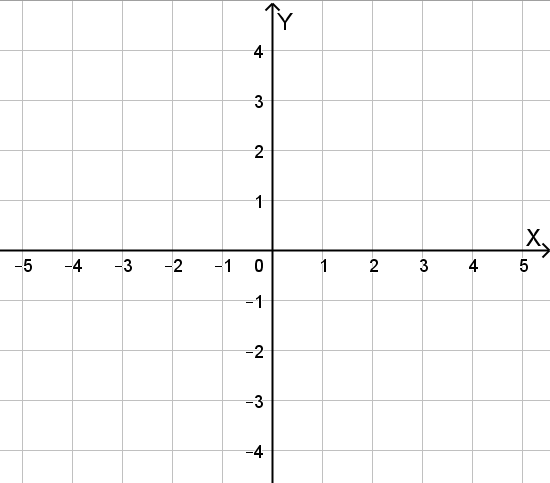


 Konsep Dasar Drawing Shapes

Sintaks umum:

```python
cv2.x(gambar, titik_awal, titik_akhir, warna_BGR, ketebalan)
cv2.x(gambar, titik_awal, RADIUS, warna_BGR, ketebalan) => KHSUUS CIRCLE

```

`x` dapat berupa:

* `line`
* `rectangle`


Parameter:

* `gambar` → image/frame target
* `titik_awal` → koordinat awal
* `titik_akhir` → koordinat akhir
* `warna_BGR` → warna dalam format BGR
* `ketebalan` → ketebalan garis


Warna pada OpenCV (BGR)

OpenCV menggunakan format warna:

```python
(B, G, R)
```

Contoh:

| Warna | Format BGR        |
| ----- | ----------------- |
| Merah | `(0, 0, 255)`     |
| Hijau | `(0, 255, 0)`     |
| Biru  | `(255, 0, 0)`     |
| Putih | `(255, 255, 255)` |
| Hitam | `(0, 0, 0)`       |

In [78]:
import cv2
import numpy as np

In [117]:
kanvas = np.zeros((500, 700,3))
print('Kanvas dibuat, ukuran (tinggi, lebar,channel):', kanvas.shape)
cv2.imshow('Drawing Demo', kanvas)

cv2.waitKey(0)
cv2.destroyAllWindows()

Kanvas dibuat, ukuran (tinggi, lebar,channel): (500, 700, 3)


penting :
- kalau sedang membuat canvas (tinggi, lebar, channel) <br> (x adalah vertikal y adalah horizontal kebalikan matematika)
- kalau sedang drawing canvas (lebar, tinggi, channel) (kembali ke matematika x adalah vertikal, y adalah horizontal)

## 04 Menggambar menggunakan CV2

### a.   MENGGAMBAR GARIS
cv2.line(gambar, titik_awal, titik_akhir, warna_BGR, ketebalan)

In [118]:
cv2.line(kanvas, (0,0), (700,500), (0,255,0), 3) #(y,x => konsep matematika)
cv2.imshow('Drawing Demo', kanvas)
cv2.waitKey(0)
cv2.destroyAllWindows()

### b. MENGGAMBAR PERSEGI PANJANG
cv2.rectangle(gambar, titik_awal, titik_akhir, warna_BGR, ketebalan)

In [114]:
cv2.rectangle(kanvas, (300,200), (400,300), (255, 0, 0), 3)
cv2.imshow('Drawing Demo', kanvas)
cv2.waitKey(0)
cv2.destroyAllWindows()

### c. MENGGAMBAR LINGKARAN
cv2.circle(gambar, titik_awal, Radius, warna_BGR, ketebalan)

In [123]:
cv2.circle(kanvas, (600, 100), 70, (0, 255, 255), 4)
cv2.circle(kanvas, (150, 350), 80, (255, 0, 255), -1)
cv2.imshow('Drawing Demo', kanvas)
cv2.waitKey(0)
cv2.destroyAllWindows()

### d. Menambahkan Teks
 cv2.putText(gambar, teks, posisi_kiri_bawah, font, ukuran_font, warna, ketebalan)


In [125]:
cv2.putText(kanvas, 'OpenCV Drawing!', (50, 470),
            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)
cv2.imshow('Drawing Demo', kanvas)
cv2.waitKey(0)
cv2.destroyAllWindows()

## 05 - Filterasisi Fungsi Esensial dalam OpenCV
Lima fungsi yang paling sering digunakan dalam pemrosesan gambar:
cvtColor, blur, Canny, dilate/erode, dan bitwise operations.

In [131]:
import cv2
import numpy as np
img = cv2.imread('images/coba.jpg')

### a. cvtColor - Konversi Warna
Berfungsi :  untuk mengubah color space atau format warna pada gambar.

In [133]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# cv2.cvtColor(gambar, kode_konversi) mengubah color space gambar
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# COLOR_BGR2RGB menukar urutan channel agar cocok dengan Matplotlib
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
# COLOR_BGR2HSV mengubah ke model warna HSV (Hue Saturation Value)

In [132]:
cv2.imshow('Original', img)
cv2.imshow('Gray', img_gray)
cv2.imshow('RGB', img_rgb)
cv2.imshow('HSV', img_hsv)
cv2.waitKey(0)
cv2.destroyAllWindows()

### b. GaussianBlur  - Fungsu Blurr gambar
Berfungsi untuk menghaluskan (blur) gambar dan mengurangi noise menggunakan metode Gaussian Filter.

In [ ]:
img_blur = cv2.GaussianBlur(img, (7, 7), 0)
# cv2.GaussianBlur(gambar, ukuran_kernel, sigmaX)
# Ukuran kernel harus ganjil: (3,3) blur ringan, (7,7) sedang, (15,15) kuat
# sigmaX=0 berarti OpenCV menghitung otomatis dari ukuran kernel

In [135]:
cv2.imshow('GaussianBlur', img_blur)
cv2.waitKey(0)
cv2.destroyAllWindows()

### c. Crop - Memotong Gambar

In [150]:
img_crop = img[100:200, 0:1]
# Memotong gambar menggunakan slicing NumPy: [baris_mulai:baris_akhir, kolom_mulai:kolom_akhir]

In [152]:
cv2.imshow('Crop Image', img_blur)
cv2.waitKey(0)
cv2.destroyAllWindows()

## 06 - Image Transformations
Transformasi geometri gambar: translasi, rotasi, flip, dan warp perspective.

In [155]:
img = cv2.imread('images/coba.jpg')
print(img.shape)

(124, 405, 3)


### a. Transalasi

In [156]:
tx = 100
ty = 50

matrix_translate = np.float32([
    [1, 0, tx],
    [0, 1, ty]
])

translated = cv2.warpAffine(
    img,
    matrix_translate,
    (img.shape[1], img.shape[0])
)

cv2.imshow('Translated', translated)
cv2.waitKey(0)
cv2.destroyAllWindows()

### b. Rotasi Gambar

In [ ]:
height = img.shape[0]
width = img.shape[1]
center = (width // 2, height // 2)
angle = 45
scale = 1.0
matrix_rotate = cv2.getRotationMatrix2D(
    center,
    angle,
    scale
)
rotated = cv2.warpAffine(
    img, # gambar 
    matrix_rotate, # mtriks 
    (width, height)
)

cv2.imshow('Rotated', rotated)
cv2.waitKey(0)
cv2.destroyAllWindows()

### c. Flip Gambar

In [158]:
flip_horizontal = cv2.flip(img, 1)
flip_vertical = cv2.flip(img, 0)
flip_both = cv2.flip(img, -1)
cv2.imshow('Flip Horizontal', flip_horizontal)
cv2.imshow('Flip Vertical', flip_vertical)
cv2.imshow('Flip Both', flip_both)
cv2.waitKey(0)
cv2.destroyAllWindows()